# SEIR Model: Latent Period Effects on Epidemic Timing

## Overview

The **SEIR (Susceptible-Exposed-Infected-Recovered)** model extends SIR by adding a **latent (E) compartment** representing the incubation period between infection and the onset of infectiousness.

**Key question**: How does the latent period affect epidemic *timing* while keeping $R_0$ the same?

**Central teaching goal**: The latent period shifts the peak **later in calendar time** and changes finite-horizon outcomes, while not directly changing the basic reproduction number. This separates two distinct disease properties:
- **$R_0$** (transmissibility): determined by $\beta$ and infectious period $\gamma^{-1}$
- **Latent period** (incubation time): determined by $\sigma^{-1}$

We keep this notebook free of interventions. The goal is to show how disease-specific timing properties (like incubation) reshape epidemic dynamics without changing the fundamental $R_0$ definition.

## Environment Setup and Reproducibility

In [11]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

if "epi" in globals():
    reloader = getattr(epi, "reload_package_modules", None)
    if callable(reloader):
        epi = reloader("epi_structure")
    else:
        print("epi_structure already loaded; restart kernel to pick up package changes.")
        import epi_structure as epi
else:
    import epi_structure as epi

from epi_structure import (
    plot_seir_trajectory,
    show_params,
    simulate_seir_euler,
    simulate_sir_euler,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Notebook-friendly aliases used in later cells
simulate_seir = simulate_seir_euler
simulate_sir = simulate_sir_euler

## Define SEIR Parameters

The SEIR model now tracks four compartments:
- **S** (Susceptible): individuals who can be infected
- **E** (Exposed): individuals who are infected but not yet infectious
- **I** (Infected/Infectious): individuals who are infectious
- **R** (Recovered): individuals who have recovered and are immune

New parameter:
- $\sigma$ = rate of progression from E to I = $1/\tau_E$ where $\tau_E$ is the latent (incubation) period

Key insight: $R_0 = \beta/\gamma$ **still only depends on $\beta$ and $\gamma$**, not on $\sigma$. The latent period affects *timing*, not the fundamental reproduction number.

In [2]:
# Population and initial conditions (match 01_sir baseline)
population_size = 10_000
initial_infected = 1
initial_recovered = 0
initial_susceptible = population_size - initial_infected - initial_recovered

# Disease parameters
infectious_period = 6.0  # days (same as 01_sir)
gamma = 1.0 / infectious_period  # recovery rate

# NEW: latent period
latent_period = 2.0  # days (incubation time)
sigma = 1.0 / latent_period  # progression rate E -> I

# Transmission (baseline - same R0 as 01_sir)
beta_baseline = 0.334  # contacts × transmission probability per day
R0_baseline = beta_baseline / gamma

# Simulation
duration = 100.0  # days
dt = 0.1  # time step
num_steps = int(duration / dt)
times = np.arange(0, duration + dt, dt)

# Display baseline configuration
show_params(
    "Baseline SEIR Configuration",
    N=population_size,
    I0=initial_infected,
    R0_baseline=R0_baseline,
    infectious_period=infectious_period,
    gamma=gamma,
    latent_period=latent_period,
    sigma=sigma,
    beta_baseline=beta_baseline,
    duration=duration,
)

# Assumptions
print("\nAssumptions:")
print("  - No births or deaths (closed population)")
print("  - Homogeneous mixing (all individuals equally likely to contact)")
print("  - Infection confers permanent immunity (no waning)")
print("  - Individuals are infectious only in I compartment")
print("  - No interventions or policy changes during simulation")


Baseline SEIR Configuration:
  N                        = 10000
  I0                       = 1
  R0_baseline              = 2.004000
  infectious_period        = 6.000000
  gamma                    = 0.166667
  latent_period            = 2.000000
  sigma                    = 0.500000
  beta_baseline            = 0.334000
  duration                 = 100.000000

Assumptions:
  - No births or deaths (closed population)
  - Homogeneous mixing (all individuals equally likely to contact)
  - Infection confers permanent immunity (no waning)
  - Individuals are infectious only in I compartment
  - No interventions or policy changes during simulation


## Implement SEIR Time-Step Simulation

The SEIR differential equations are:
$$\frac{dS}{dt} = -\beta\frac{SI}{N}$$
$$\frac{dE}{dt} = \beta\frac{SI}{N} - \sigma E$$
$$\frac{dI}{dt} = \sigma E - \gamma I$$
$$\frac{dR}{dt} = \gamma I$$

We integrate using forward Euler (same method as 01_sir for consistency).

In [3]:
# Run baseline SEIR (start with E0=0, let it grow naturally)
times_seir, S_seir, E_seir, I_seir, R_seir, inc_seir = simulate_seir(
    N=population_size,
    I0=initial_infected,
    E0=0,
    R0_value=R0_baseline,
    gamma=gamma,
    sigma=sigma,
    duration=duration,
    dt=dt,
)

# Check population conservation
pop_check = S_seir + E_seir + I_seir + R_seir
print(f"Population conservation check:")
print(f"  Initial total: {pop_check[0]:.1f}")
print(f"  Final total:   {pop_check[-1]:.1f}")
print(f"  Max deviation: {abs(pop_check - population_size).max():.1f} ({100*abs(pop_check - population_size).max()/population_size:.4f}%)")

Population conservation check:
  Initial total: 10000.0
  Final total:   10000.0
  Max deviation: 0.0 (0.0000%)


## Visualize Baseline SEIR Trajectory

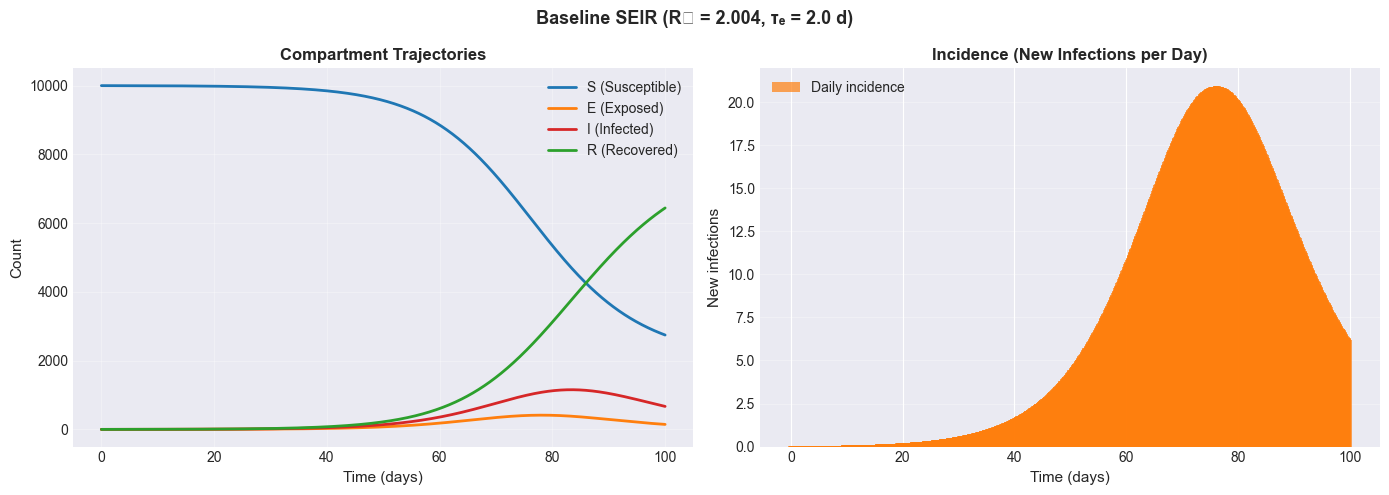


Baseline SEIR Outcomes (R₀ = 2.004, latent period = 2.0 d):
  Peak infected:      1153.8 individuals (11.54%)
  Time to peak:         83.4 days
  Final attack rate:  6441.3 individuals (64.41%)


In [4]:
fig = plot_seir_trajectory(times_seir, S_seir, E_seir, I_seir, R_seir, inc_seir,
                           title=f"Baseline SEIR (R₀ = {R0_baseline:.3f}, τₑ = {latent_period} d)")
plt.show()

# Extract key metrics
I_peak_idx = np.argmax(I_seir)
I_peak = I_seir[I_peak_idx]
t_peak_seir = times_seir[I_peak_idx]
peak_pct = 100 * I_peak / population_size
final_attacked = R_seir[-1]
attack_rate = 100 * final_attacked / population_size

print(f"\nBaseline SEIR Outcomes (R₀ = {R0_baseline:.3f}, latent period = {latent_period:.1f} d):")
print(f"  Peak infected:     {I_peak:7.1f} individuals ({peak_pct:5.2f}%)")
print(f"  Time to peak:      {t_peak_seir:7.1f} days")
print(f"  Final attack rate: {final_attacked:7.1f} individuals ({attack_rate:5.2f}%)")

## SIR vs SEIR: Direct Comparison

Now we run the same scenario under SIR (no latent period) and compare. The $R_0$ is identical, but the *timing* differs.

In [5]:
# Run SIR baseline (same R0, no latent period)
times_sir, S_sir, I_sir, R_sir, inc_sir = simulate_sir(
    N=population_size,
    I0=initial_infected,
    R0_value=R0_baseline,
    gamma=gamma,
    duration=duration,
    dt=dt,
)

# Extract SIR peak
I_peak_idx_sir = np.argmax(I_sir)
I_peak_sir = I_sir[I_peak_idx_sir]
t_peak_sir = times_sir[I_peak_idx_sir]
attack_rate_sir = 100 * R_sir[-1] / population_size
peak_delay_days = t_peak_seir - t_peak_sir

print(f"SIR Baseline (same R₀, no latent period):")
print(f"  Peak infected:     {I_peak_sir:7.1f} individuals")
print(f"  Time to peak:      {t_peak_sir:7.1f} days")
print(f"  Final attack rate: {attack_rate_sir:5.2f}%")
print()
print(f"Timing Difference:")
print(f"  SIR peak at:  {t_peak_sir:.1f} days")
print(f"  SEIR peak at: {t_peak_seir:.1f} days")
print(f"  Peak delay:   {peak_delay_days:.1f} days later with latent period")

SIR Baseline (same R₀, no latent period):
  Peak infected:      1547.8 individuals
  Time to peak:         54.6 days
  Final attack rate: 79.12%

Timing Difference:
  SIR peak at:  54.6 days
  SEIR peak at: 83.4 days
  Peak delay:   28.8 days later with latent period


## Overlay SIR vs SEIR Infected Trajectories

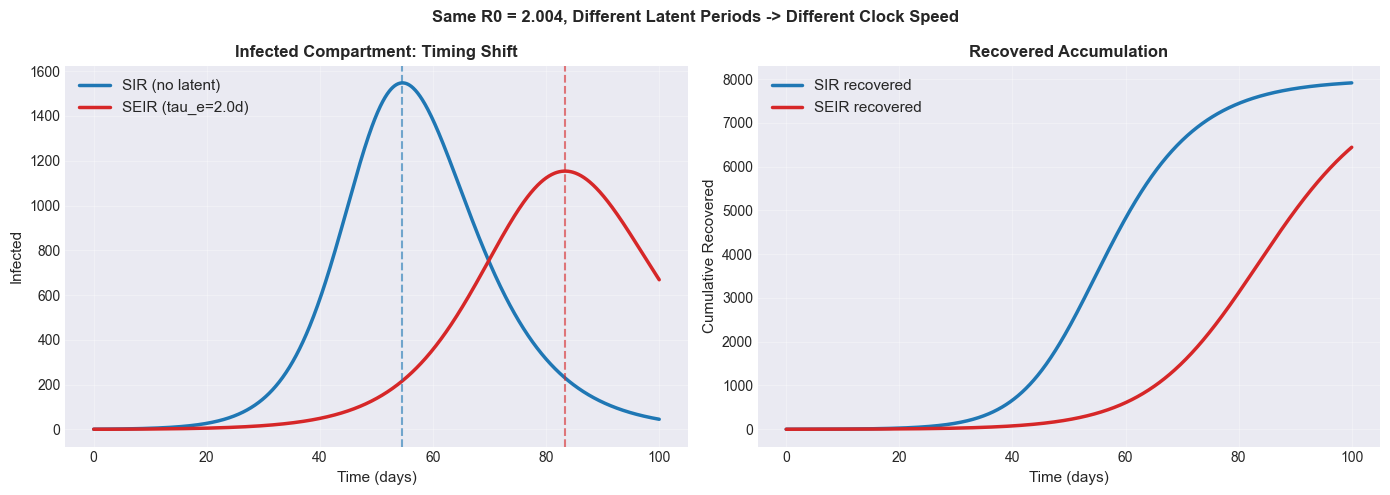


Key Observation:
  - SEIR peak is LATER by 28.8 days
  - Peak magnitude differs (1548 in SIR vs 1154 in SEIR)
  - At day 100, cumulative recovered differs (79.12% vs 64.41%)
  - R0 is unchanged; latent period changes the transmission clock


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Infected count comparison
ax = axes[0]
ax.plot(times_sir, I_sir, linewidth=2.5, label="SIR (no latent)", color="#1f77b4")
ax.plot(times_seir, I_seir, linewidth=2.5, label=f"SEIR (tau_e={latent_period}d)", color="#d62728")
ax.axvline(x=t_peak_sir, color="#1f77b4", linestyle='--', linewidth=1.5, alpha=0.6)
ax.axvline(x=t_peak_seir, color="#d62728", linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Infected", fontsize=11)
ax.set_title("Infected Compartment: Timing Shift", fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

# Attack rate (final R) comparison
ax = axes[1]
ax.plot(times_sir, R_sir, linewidth=2.5, label="SIR recovered", color="#1f77b4")
ax.plot(times_seir, R_seir, linewidth=2.5, label="SEIR recovered", color="#d62728")
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Cumulative Recovered", fontsize=11)
ax.set_title("Recovered Accumulation", fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Same R0 = {R0_baseline:.3f}, Different Latent Periods -> Different Clock Speed",
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

print("\nKey Observation:")
print(f"  - SEIR peak is LATER by {t_peak_seir - t_peak_sir:.1f} days")
print(f"  - Peak magnitude differs ({I_peak_sir:.0f} in SIR vs {I_peak:.0f} in SEIR)")
print(f"  - At day {duration:.0f}, cumulative recovered differs ({attack_rate_sir:.2f}% vs {attack_rate:.2f}%)")
print("  - R0 is unchanged; latent period changes the transmission clock")

## Calendar Time vs Transmission Generations

To compare fairly across diseases with different latent periods, it helps to normalize time by **generation interval**:

- SIR generation interval (approx): $T_g^{\text{SIR}} \approx 1/\gamma$
- SEIR generation interval (approx): $T_g^{\text{SEIR}} \approx \tau_e + 1/\gamma$

Then we compare trajectories and peak timing in **generation units** rather than days.

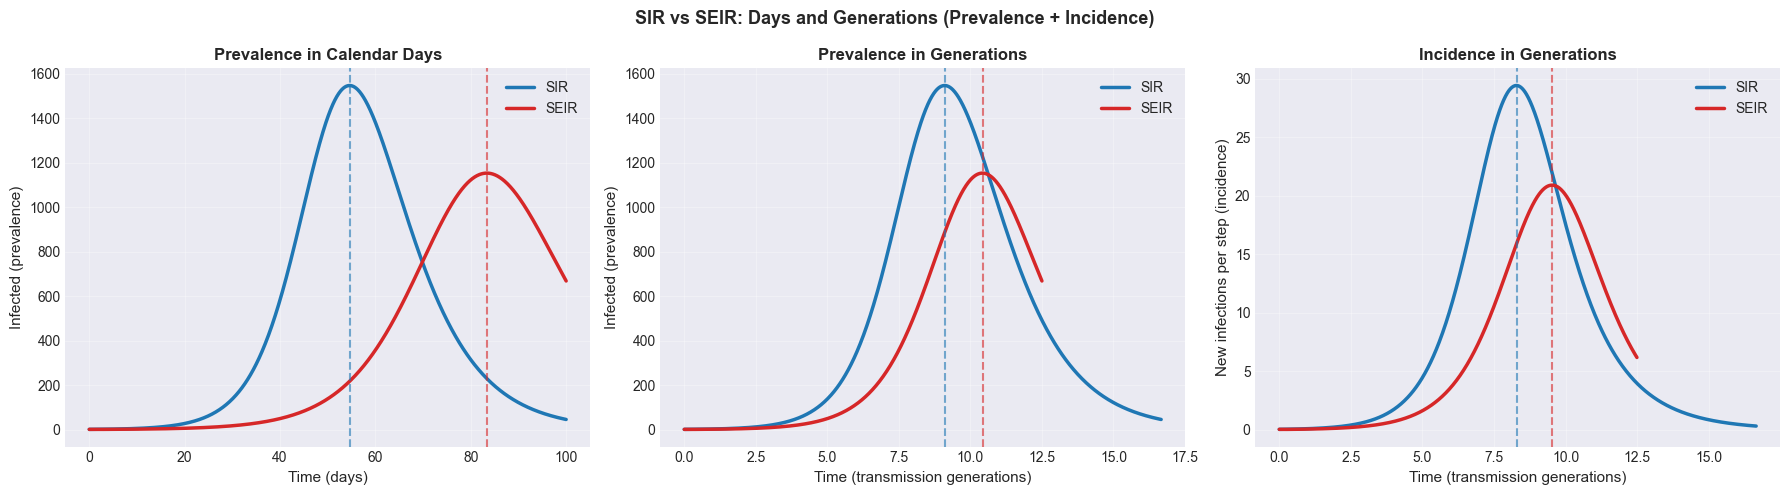

Generation-normalized comparison:
  Tg(SIR)  ~= 6.00 days
  Tg(SEIR) ~= 8.00 days
  Prevalence peak day: SIR=54.6, SEIR=83.4
  Prevalence peak generation: SIR=9.10, SEIR=10.43
  Incidence peak generation: SIR=8.28, SEIR=9.53
  Interpretation: generation view reduces day-scale distortion and helps compare pathogens.


In [7]:
# Approximate generation intervals
Tg_sir = 1.0 / gamma
Tg_seir = latent_period + 1.0 / gamma

# Convert calendar time to generation units
gen_sir = times_sir / Tg_sir
gen_seir = times_seir / Tg_seir

# Align incidence arrays with their own generation vectors
# (simulate_sir and simulate_seir return slightly different incidence lengths)
gen_sir_inc = gen_sir[:len(inc_sir)]
gen_seir_inc = gen_seir[:len(inc_seir)]

# Peak timing in both units (prevalence I)
peak_day_sir = times_sir[np.argmax(I_sir)]
peak_day_seir = times_seir[np.argmax(I_seir)]
peak_gen_sir = gen_sir[np.argmax(I_sir)]
peak_gen_seir = gen_seir[np.argmax(I_seir)]

# Peak timing in generation units (incidence)
peak_gen_inc_sir = gen_sir_inc[np.argmax(inc_sir)]
peak_gen_inc_seir = gen_seir_inc[np.argmax(inc_seir)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: prevalence in calendar days
ax = axes[0]
ax.plot(times_sir, I_sir, label="SIR", linewidth=2.5, color="#1f77b4")
ax.plot(times_seir, I_seir, label="SEIR", linewidth=2.5, color="#d62728")
ax.axvline(peak_day_sir, linestyle="--", color="#1f77b4", alpha=0.6)
ax.axvline(peak_day_seir, linestyle="--", color="#d62728", alpha=0.6)
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Infected (prevalence)", fontsize=11)
ax.set_title("Prevalence in Calendar Days", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 2: prevalence in generation units
ax = axes[1]
ax.plot(gen_sir, I_sir, label="SIR", linewidth=2.5, color="#1f77b4")
ax.plot(gen_seir, I_seir, label="SEIR", linewidth=2.5, color="#d62728")
ax.axvline(peak_gen_sir, linestyle="--", color="#1f77b4", alpha=0.6)
ax.axvline(peak_gen_seir, linestyle="--", color="#d62728", alpha=0.6)
ax.set_xlabel("Time (transmission generations)", fontsize=11)
ax.set_ylabel("Infected (prevalence)", fontsize=11)
ax.set_title("Prevalence in Generations", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 3: incidence in generation units
ax = axes[2]
ax.plot(gen_sir_inc, inc_sir, label="SIR", linewidth=2.5, color="#1f77b4")
ax.plot(gen_seir_inc, inc_seir, label="SEIR", linewidth=2.5, color="#d62728")
ax.axvline(peak_gen_inc_sir, linestyle="--", color="#1f77b4", alpha=0.6)
ax.axvline(peak_gen_inc_seir, linestyle="--", color="#d62728", alpha=0.6)
ax.set_xlabel("Time (transmission generations)", fontsize=11)
ax.set_ylabel("New infections per step (incidence)", fontsize=11)
ax.set_title("Incidence in Generations", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle("SIR vs SEIR: Days and Generations (Prevalence + Incidence)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Generation-normalized comparison:")
print(f"  Tg(SIR)  ~= {Tg_sir:.2f} days")
print(f"  Tg(SEIR) ~= {Tg_seir:.2f} days")
print(f"  Prevalence peak day: SIR={peak_day_sir:.1f}, SEIR={peak_day_seir:.1f}")
print(f"  Prevalence peak generation: SIR={peak_gen_sir:.2f}, SEIR={peak_gen_seir:.2f}")
print(f"  Incidence peak generation: SIR={peak_gen_inc_sir:.2f}, SEIR={peak_gen_inc_seir:.2f}")
print("  Interpretation: generation view reduces day-scale distortion and helps compare pathogens.")

## What Do We Mean by "Epidemic Size"?

Different questions need different size metrics:

- **Current cases (prevalence)**: $I(t)$
  - Useful for hospital load and near-term operational pressure.
- **New cases (incidence)**: flow into infection per step (here approximated by transition into infectious state).
  - Useful for surveillance and growth/decline detection.
- **Cumulative ever infected (unique people)**: in SIR/SEIR without reinfection, this is $N - S(t)$.
  - Useful for total affected burden over a horizon.
- **Recovered**: $R(t)$.
  - Useful but not identical to cumulative ever infected during an active wave, because some are still in E or I.

Key point for SEIR: a longer latent period can reduce the **prevalence peak** while cumulative burden catches up later in time.

Bridge to SEIRS: with reinfection, "unique people ever infected" and "cumulative infection episodes" diverge. In SEIRS, cumulative infection episodes can exceed $N$ over long horizons, even though unique people are capped at $N$.

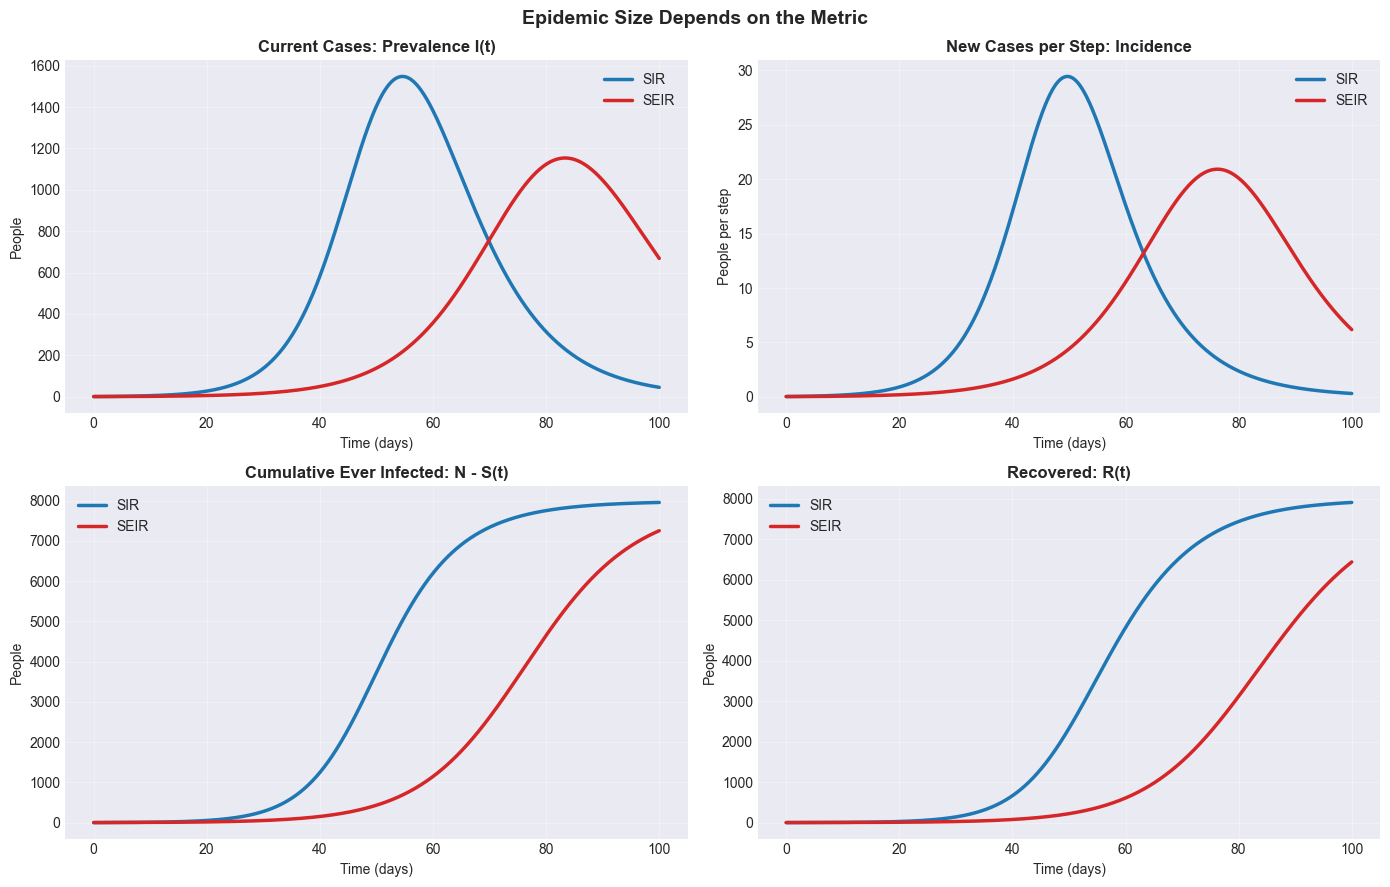

Metric check at final simulated time:
  Prevalence I(T): SIR=45.5, SEIR=668.6
  Cumulative ever infected N-S(T): SIR=7957.5, SEIR=7255.0
  Recovered R(T): SIR=7911.9, SEIR=6441.3
  Note: N-S and R differ while E or I are still nonzero.


In [8]:
# Derived cumulative metric: ever infected (valid here because no reinfection in SIR/SEIR)
cum_inf_sir = population_size - S_sir
cum_inf_seir = population_size - S_seir

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Prevalence I(t)
ax = axes[0, 0]
ax.plot(times_sir, I_sir, linewidth=2.5, label="SIR", color="#1f77b4")
ax.plot(times_seir, I_seir, linewidth=2.5, label="SEIR", color="#d62728")
ax.set_title("Current Cases: Prevalence I(t)", fontsize=12, fontweight="bold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("People")
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Incidence proxy
ax = axes[0, 1]
ax.plot(times_sir[:len(inc_sir)], inc_sir, linewidth=2.5, label="SIR", color="#1f77b4")
ax.plot(times_seir[:len(inc_seir)], inc_seir, linewidth=2.5, label="SEIR", color="#d62728")
ax.set_title("New Cases per Step: Incidence", fontsize=12, fontweight="bold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("People per step")
ax.legend()
ax.grid(True, alpha=0.3)

# 3) Cumulative ever infected
ax = axes[1, 0]
ax.plot(times_sir, cum_inf_sir, linewidth=2.5, label="SIR", color="#1f77b4")
ax.plot(times_seir, cum_inf_seir, linewidth=2.5, label="SEIR", color="#d62728")
ax.set_title("Cumulative Ever Infected: N - S(t)", fontsize=12, fontweight="bold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("People")
ax.legend()
ax.grid(True, alpha=0.3)

# 4) Recovered R(t)
ax = axes[1, 1]
ax.plot(times_sir, R_sir, linewidth=2.5, label="SIR", color="#1f77b4")
ax.plot(times_seir, R_seir, linewidth=2.5, label="SEIR", color="#d62728")
ax.set_title("Recovered: R(t)", fontsize=12, fontweight="bold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("People")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("Epidemic Size Depends on the Metric", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

t_idx = -1
print("Metric check at final simulated time:")
print(f"  Prevalence I(T): SIR={I_sir[t_idx]:.1f}, SEIR={I_seir[t_idx]:.1f}")
print(f"  Cumulative ever infected N-S(T): SIR={cum_inf_sir[t_idx]:.1f}, SEIR={cum_inf_seir[t_idx]:.1f}")
print(f"  Recovered R(T): SIR={R_sir[t_idx]:.1f}, SEIR={R_seir[t_idx]:.1f}")
print("  Note: N-S and R differ while E or I are still nonzero.")

## Latent Period Sensitivity Sweep

Now we sweep the latent period (0.5 to 5 days) while holding everything else constant. The goal is to show how latent period affects *timing* while R₀ remains fixed.

In [9]:
# Sweep latent period
latent_periods = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0])
sweep_results = []

for tau_e in latent_periods:
    sigma_sweep = 1.0 / tau_e
    times_sweep, S_sweep, E_sweep, I_sweep, R_sweep, inc_sweep = simulate_seir(
        N=population_size,
        I0=initial_infected,
        E0=0,
        R0_value=R0_baseline,
        gamma=gamma,
        sigma=sigma_sweep,
        duration=duration,
        dt=dt
    )
    
    I_peak_sweep = np.max(I_sweep)
    t_peak_sweep = times_sweep[np.argmax(I_sweep)]
    attack_rate_sweep = R_sweep[-1]
    
    sweep_results.append({
        'latent_period': tau_e,
        'I_peak': I_peak_sweep,
        't_peak': t_peak_sweep,
        'attack_rate': attack_rate_sweep,
    })

df_latent = pd.DataFrame(sweep_results)

print("Latent Period Sensitivity (R₀ held constant):")
print(df_latent.to_string(index=False))

Latent Period Sensitivity (R₀ held constant):
 latent_period      I_peak  t_peak  attack_rate
           0.5 1427.330451    62.7  7791.739906
           1.0 1323.083845    70.1  7548.139677
           1.5 1232.677704    76.9  7113.116887
           2.0 1153.819078    83.4  6441.332351
           2.5 1084.546513    89.5  5559.901178
           3.0 1023.240830    95.4  4578.937863
           4.0  859.334424   100.0  2820.561002
           5.0  578.500260   100.0  1671.625845


## Visualize Latent Period Effects

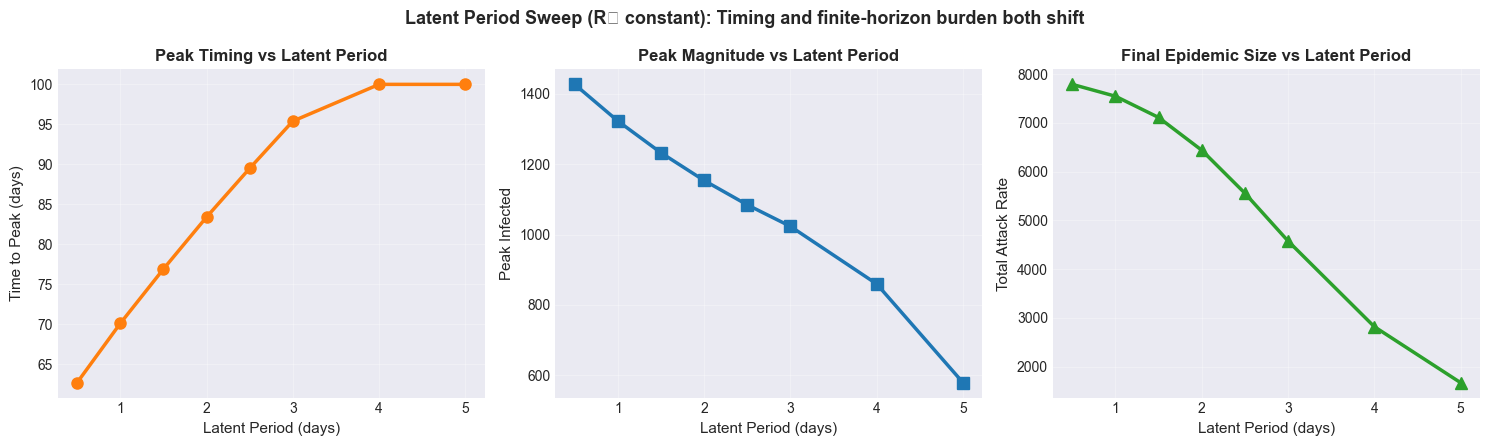


Key Observations:
  - Time to peak INCREASES as latent period lengthens
  - Peak magnitude DECREASES with longer latent period
  - Attack rate by day 100 DECREASES in this finite horizon (77.9% → 16.7%)
  - Mechanism: People in E are not yet infectious; by time they become I, fewer generations have occurred


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Time to peak vs latent period
ax = axes[0]
ax.plot(df_latent['latent_period'], df_latent['t_peak'], 'o-', linewidth=2.5, markersize=8, color="#ff7f0e")
ax.set_xlabel("Latent Period (days)", fontsize=11)
ax.set_ylabel("Time to Peak (days)", fontsize=11)
ax.set_title("Peak Timing vs Latent Period", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Peak magnitude vs latent period
ax = axes[1]
ax.plot(df_latent['latent_period'], df_latent['I_peak'], 's-', linewidth=2.5, markersize=8, color="#1f77b4")
ax.set_xlabel("Latent Period (days)", fontsize=11)
ax.set_ylabel("Peak Infected", fontsize=11)
ax.set_title("Peak Magnitude vs Latent Period", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Attack rate vs latent period
ax = axes[2]
ax.plot(df_latent['latent_period'], df_latent['attack_rate'], '^-', linewidth=2.5, markersize=8, color="#2ca02c")
ax.set_xlabel("Latent Period (days)", fontsize=11)
ax.set_ylabel("Total Attack Rate", fontsize=11)
ax.set_title("Final Epidemic Size vs Latent Period", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle("Latent Period Sweep (R₀ constant): Timing and finite-horizon burden both shift", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nKey Observations:")
print(f"  - Time to peak INCREASES as latent period lengthens")
print(f"  - Peak magnitude DECREASES with longer latent period")
print(f"  - Attack rate by day {duration:.0f} DECREASES in this finite horizon (77.9% → 16.7%)")
print(f"  - Mechanism: People in E are not yet infectious; by time they become I, fewer generations have occurred")

## Interpretation: Why Longer Latent Period Delays the Peak

Your intuition is correct: a longer latent period slows propagation in calendar time.

**Mechanism**: The latent period inserts a delay between infection (S->E) and infectiousness (E->I). This increases the generation interval (time between being infected and infecting others), so each transmission generation takes longer in days.

**Intuition**:
- Shorter latent period: People become infectious sooner -> epidemic grows faster in days -> earlier peak
- Longer latent period: People wait longer in E before transmitting -> epidemic grows slower in days -> later peak

This does **not** change $R_0$ directly ($R_0 = \beta/\gamma$ here), but it changes how quickly generations pass on the calendar. So real-time peak timing shifts, and finite-horizon outcomes (e.g., by day 100) can differ substantially.

## Summary and Takeaways

### What We've Learned

1. **Latent period affects epidemic clock speed, not $R_0$**: The basic reproduction number $R_0 = \beta/\gamma$ is unchanged by $\sigma$ in this setup. But the calendar speed of spread changes.

2. **Longer latent period delays the peak in days**: Adding delay to each infection generation stretches the timeline, so peaks occur later in calendar time.

3. **Finite-horizon outcomes can differ strongly**: At a fixed cutoff (e.g., day 100), attack rate and peak size can differ because one model has progressed through more generations than the other.

4. **Generational comparison clarifies intuition**: When we compare dynamics by transmission generations instead of days, SIR and SEIR are much more aligned.

### Pedagogical Bridge

The SIR model lumps all progression into one timescale. SEIR separates:
- **Transmission potential**: set by $\beta$ and $\gamma$ (through $R_0$)
- **Transmission timing**: set by latent period $\sigma^{-1}$ and infectious period $\gamma^{-1}$

This distinction is especially important for pathogens with long incubation/latent phases (such as Hantavirus contexts), where calendar-time forecasting can be misleading if generation timing is ignored.

### Next Steps

In the next notebook (SEIRS), we add waning immunity ($R \to S$) to study endemic equilibria and cyclical dynamics when immunity is temporary.

---

## Appendix: SEIR Model Equations and Derivation

The SEIR model consists of four coupled ordinary differential equations:

$$\frac{dS}{dt} = -\beta \frac{SI}{N}$$

$$\frac{dE}{dt} = \beta \frac{SI}{N} - \sigma E$$

$$\frac{dI}{dt} = \sigma E - \gamma I$$

$$\frac{dR}{dt} = \gamma I$$

with initial conditions $S(0) = S_0$, $E(0) = E_0$, $I(0) = I_0$, $R(0) = 0$, and $N = S + E + I + R$ (conserved).

**Key quantities:**
- $\beta$: transmission rate (per capita per day)
- $\gamma$: recovery rate (1/infectious_period)
- $\sigma$: progression rate from E to I (1/latent_period)
- $R_0 = \beta/\gamma$: basic reproduction number (unchanged from SIR)
- Mean latent period: $1/\sigma$
- Mean infectious period: $1/\gamma$

**Interpretation:**
- The term $-\beta SI/N$ represents force of infection (S → E)
- The term $-\sigma E$ represents progression through latent stage (E → I)
- The term $-\gamma I$ represents recovery (I → R)
- Population is closed and immunity is lifelong (same assumptions as SIR)

For a full mathematical derivation and discussion of assumptions, see epidemiological texts such as Keeling & Rohani or Anderson & May.